1. Data Loading & Data Cleaning

In [1]:
import pandas as pd

url_cases = "https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_confirmed_US.csv"
url_deaths = "https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_deaths_US.csv"

cases = pd.read_csv(url_cases)
deaths = pd.read_csv(url_deaths)

#Data Cleaning
cases = cases[['Province_State', 'Admin2', 'Lat', 'Long_'] + list(cases.columns[11:])]
deaths = deaths[['Province_State', 'Admin2', 'Lat', 'Long_'] + list(deaths.columns[12:])]

cases_state = cases.drop(['Admin2'], axis=1).groupby('Province_State').sum()
deaths_state = deaths.drop(['Admin2'], axis=1).groupby('Province_State').sum()

#Checking for missing values
print("Missing values in cases dataset:", cases_state.isnull().sum().sum())
print("Missing values in deaths dataset:", deaths_state.isnull().sum().sum())


Missing values in cases dataset: 0
Missing values in deaths dataset: 0


(EDA)

In [2]:
#Exploratory Data Analysis
latest_cases = cases_state.iloc[:, -1]
latest_deaths = deaths_state.iloc[:, -1]

summary_df = pd.DataFrame({
    'State': latest_cases.index,
    'Total Cases': latest_cases.values,
    'Total Deaths': latest_deaths.values
})

#summary statistics
print(summary_df.describe())


        Total Cases   Total Deaths
count  5.800000e+01      58.000000
mean   1.789702e+06   19376.482759
std    2.246775e+06   23326.992865
min    4.900000e+01       0.000000
25%    3.427018e+05    3223.500000
50%    1.048614e+06   12620.000000
75%    2.181029e+06   24166.250000
max    1.212970e+07  101159.000000


3. Data Manipulation (Aggregation)

In [3]:
#Creating a summary dataframe with total cases and deaths per state
summary_df.head()

,State,Total Cases,Total Deaths
0,Alabama,1644533,21032
1,Alaska,307655,1486
2,American Samoa,8320,34
3,Arizona,2443514,33102
4,Arkansas,1006883,13020


4. Map Visualization 1: Choropleth Map

In [4]:
import plotly.express as px

# Mapping state names to abbreviations
us_state_abbrev = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR',
    'California': 'CA', 'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE',
    'District of Columbia': 'DC', 'Florida': 'FL', 'Georgia': 'GA', 'Hawaii': 'HI',
    'Idaho': 'ID', 'Illinois': 'IL', 'Indiana': 'IN', 'Iowa': 'IA', 'Kansas': 'KS',
    'Kentucky': 'KY', 'Louisiana': 'LA', 'Maine': 'ME', 'Maryland': 'MD',
    'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN', 'Mississippi': 'MS',
    'Missouri': 'MO', 'Montana': 'MT', 'Nebraska': 'NE', 'Nevada': 'NV',
    'New Hampshire': 'NH', 'New Jersey': 'NJ', 'New Mexico': 'NM',
    'New York': 'NY', 'North Carolina': 'NC', 'North Dakota': 'ND',
    'Ohio': 'OH', 'Oklahoma': 'OK', 'Oregon': 'OR', 'Pennsylvania': 'PA',
    'Rhode Island': 'RI', 'South Carolina': 'SC', 'South Dakota': 'SD',
    'Tennessee': 'TN', 'Texas': 'TX', 'Utah': 'UT', 'Vermont': 'VT',
    'Virginia': 'VA', 'Washington': 'WA', 'West Virginia': 'WV',
    'Wisconsin': 'WI', 'Wyoming': 'WY'
}

# Add a new column for abbreviations
summary_df['State_Abbrev'] = summary_df['State'].map(us_state_abbrev)

# Now plot with correct abbreviations
fig_choropleth = px.choropleth(
    summary_df,
    locations='State_Abbrev',  # Use the 2-letter abbreviation
    locationmode="USA-states",
    color='Total Cases',
    scope="usa",
    title='COVID-19 Total Cases by State (Choropleth Map)',
    color_continuous_scale="Reds"
)
fig_choropleth.show()



5. Map Visualization 2: Bubble Map

In [5]:
import folium
from folium.plugins import MarkerCluster

usa_map = folium.Map(location=[37.0902, -95.7129], zoom_start=4)
marker_cluster = MarkerCluster().add_to(usa_map)

for i in range(len(summary_df)):
    state_data = cases[cases['Province_State'] == summary_df.iloc[i]['State']]
    lat = state_data['Lat'].mean()
    lon = state_data['Long_'].mean()

    folium.CircleMarker(
        location=[lat, lon],
        radius=max(summary_df.iloc[i]['Total Deaths'] / 5000, 2),
        popup=(f"{summary_df.iloc[i]['State']}<br>Deaths: {summary_df.iloc[i]['Total Deaths']}"),
        color='crimson',
        fill=True,
        fill_color='crimson'
    ).add_to(marker_cluster)

display(usa_map)


6. Aggregation Visualization 1: Histogram

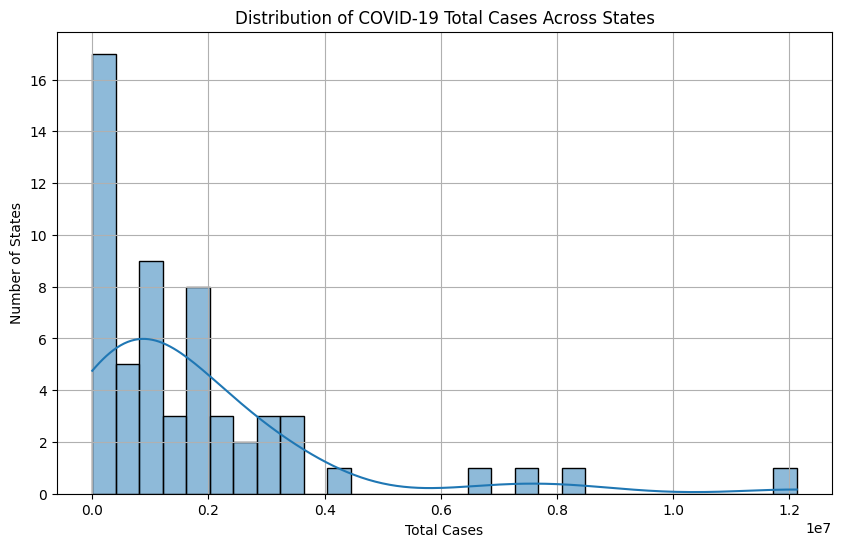

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.histplot(summary_df['Total Cases'], bins=30, kde=True)
plt.title('Distribution of COVID-19 Total Cases Across States')
plt.xlabel('Total Cases')
plt.ylabel('Number of States')
plt.grid(True)
plt.show()


7. Aggregation Visualization 2: Boxplot

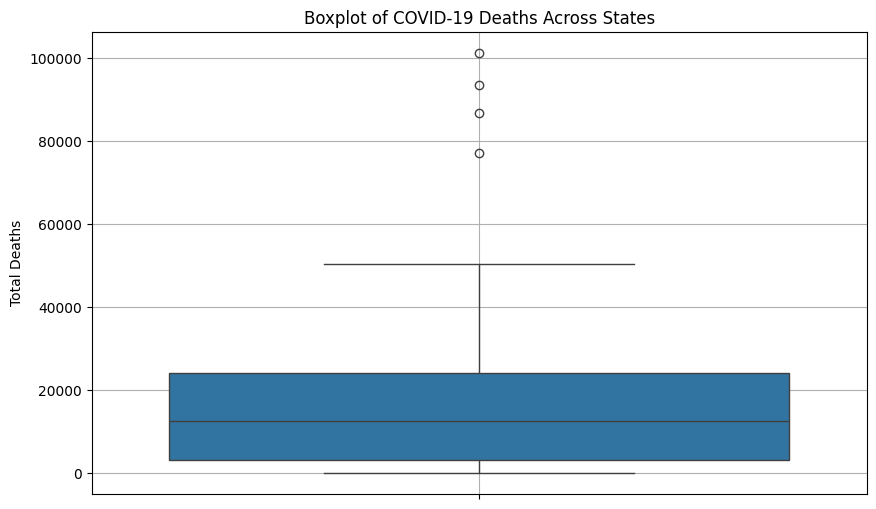

In [7]:
plt.figure(figsize=(10,6))
sns.boxplot(y=summary_df['Total Deaths'])
plt.title('Boxplot of COVID-19 Deaths Across States')
plt.ylabel('Total Deaths')
plt.grid(True)
plt.show()


8. Interactive Visualization: Time Series with Scrubbing

In [8]:
date_cols = cases.columns[4:]
cases_only_dates = cases[date_cols]
usa_timeseries = cases_only_dates.sum(axis=0)
usa_timeseries.index = pd.to_datetime(usa_timeseries.index)

fig_timeseries = px.line(
    x=usa_timeseries.index,
    y=usa_timeseries.values,
    labels={'x': 'Date', 'y': 'Total Cases'},
    title='COVID-19 Cumulative Cases Over Time in the USA'
)
fig_timeseries.update_layout(hovermode='x unified')
fig_timeseries.show()


<ipython-input-8-de18da79ddc3>:4: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.



Conclusion

In [9]:

print("""
Key Observations:
- States like California, Texas, and Florida recorded the highest case numbers.
- Death counts are heavily skewed; a few states account for the majority.
- COVID-19 cases grew exponentially during early phases (2020).
- The bubble map shows clusters of high mortality regions (e.g., New York, California).
""")



Key Observations:
- States like California, Texas, and Florida recorded the highest case numbers.
- Death counts are heavily skewed; a few states account for the majority.
- COVID-19 cases grew exponentially during early phases (2020).
- The bubble map shows clusters of high mortality regions (e.g., New York, California).

